# Этап 1. Исследовательский анализ  данных (EDA)

In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

DATA_PATH = 'data/'
INGREDIENTS_PATH = os.path.join(DATA_PATH, 'ingredients.csv')
DISH_PATH = os.path.join(DATA_PATH, 'dish.csv')
IMAGES_PATH = os.path.join(DATA_PATH, 'images')

df_ingredients = pd.read_csv(INGREDIENTS_PATH)
df_dish = pd.read_csv(DISH_PATH)

ingredients_dict = dict(zip(df_ingredients['id'].astype(str), df_ingredients['ingr']))


### Общий анализ данных

In [15]:
print("ТАБЛИЦА ИНГРЕДИЕНТОВ")

print(f"\nРазмер таблицы: {df_ingredients.shape}")

print(f"\nСтолбцы: {df_ingredients.columns.tolist()}")
print(f"\nТипы данных:\n{df_ingredients.dtypes}")
print(f"\nПропуски:\n{df_ingredients.isnull().sum()}")
print("\n")
print(df_ingredients.head(10))
print("\n\n")

print("ТАБЛИЦА БЛЮД")

print(f"Размер таблицыд: {df_dish.shape}")

print(f"\nСтолбцы: {df_dish.columns.tolist()}")
print(f"\nТипы данных:\n{df_dish.dtypes}")
print(f"\nПропуски:\n{df_dish.isnull().sum()}")
print(f"\n")
print(df_dish.head(10))

ТАБЛИЦА ИНГРЕДИЕНТОВ

Размер таблицы: (555, 2)

Столбцы: ['id', 'ingr']

Типы данных:
id      int64
ingr      str
dtype: object

Пропуски:
id      0
ingr    0
dtype: int64


   id            ingr
0   1  cottage cheese
1   2    strawberries
2   3    garden salad
3   4           bacon
4   5        potatoes
5   6    caesar salad
6   7     cauliflower
7   8  scrambled eggs
8   9       wild rice
9  10           steak



ТАБЛИЦА БЛЮД
Размер таблицыд: (3262, 6)

Столбцы: ['dish_id', 'total_calories', 'total_mass', 'ingredients', 'split', 'num_ingredients']

Типы данных:
dish_id                str
total_calories     float64
total_mass         float64
ingredients            str
split                  str
num_ingredients      int64
dtype: object

Пропуски:
dish_id            0
total_calories     0
total_mass         0
ingredients        0
split              0
num_ingredients    0
dtype: int64


           dish_id  total_calories  total_mass  \
0  dish_1561662216      300.794281       193.0   
1 

### Распределение по split


Распределение по split:
split
train    2755
test      507
Name: count, dtype: int64

Доля обучающей выборки: 84.5%
Доля тестовой выборки: 15.5%


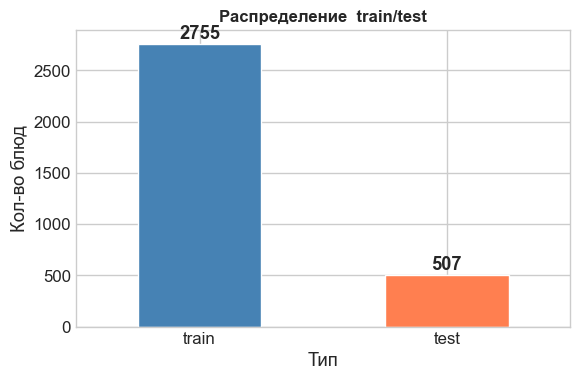

In [24]:
import matplotlib.pyplot as plt

split_counts = df_dish['split'].value_counts()
print("\nРаспределение по split:")
print(split_counts)

print(f"\nДоля обучающей выборки: "
      f"{split_counts['train'] / len(df_dish) * 100:.1f}%")
print(f"Доля тестовой выборки: "
      f"{split_counts['test'] / len(df_dish) * 100:.1f}%")

plt.figure(figsize=(6, 4))

ax = split_counts.plot(
    kind='bar',
    color=['steelblue', 'coral'],
    rot=0 
)

ax.set_title('Распределение  train/test',
             fontsize=12,
             fontweight='bold')   
ax.set_xlabel('Тип')
ax.set_ylabel('Кол-во блюд')

for i, v in enumerate(split_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Распределение по калориям


Статистика по total_calories
count    3262.000000
mean      255.012738
std       219.637570
min         0.000000
25%        80.114996
50%       209.110062
75%       375.122963
max      3943.325195
Name: total_calories, dtype: float64


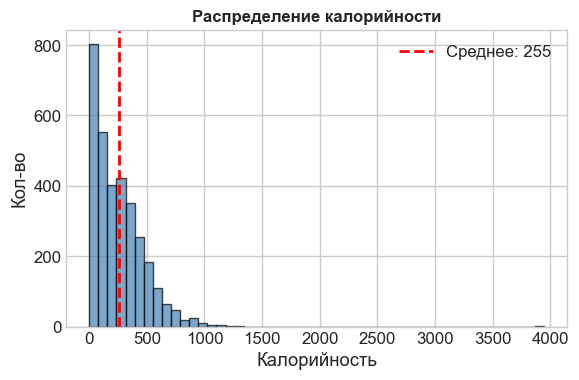

In [30]:
print(f"\nСтатистика по total_calories")
print(df_dish['total_calories'].describe())


plt.figure(figsize=(6, 4))
ax = plt.gca()                                 

ax.hist(
    df_dish['total_calories'],
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='steelblue'
)

mean_val = df_dish['total_calories'].mean()
ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее: {mean_val:.0f}'
)

ax.set_title(
    'Распределение калорийности',
    fontsize=12,
    fontweight='bold'        
)
ax.set_xlabel('Калорийность')
ax.set_ylabel('Кол-во')
ax.legend()

plt.tight_layout()
plt.show()

### Распределение по массе


Статистика по total_mass
count    3262.000000
mean      214.980074
std       161.497428
min         1.000000
25%        92.000000
50%       177.000000
75%       305.000000
max      3051.000000
Name: total_mass, dtype: float64


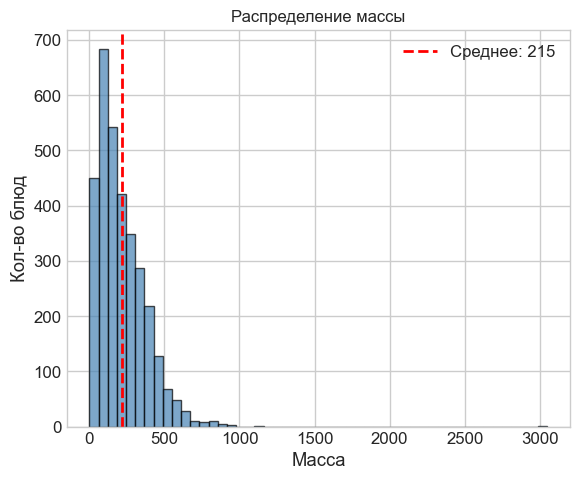

In [33]:
print(f"\nСтатистика по total_mass")
print(df_dish['total_mass'].describe())

plt.figure(figsize=(6, 5))
ax = plt.gca()                                

ax.hist(
    df_dish['total_mass'],
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='steelblue'
)

mean_val = df_dish['total_mass'].mean()
ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее: {mean_val:.0f}'
)

ax.set_title(
    'Распределение массы',
    fontsize=12,
)
ax.set_xlabel('Масса')
ax.set_ylabel('Кол-во блюд')
ax.legend()

plt.tight_layout()
plt.show()

### Распределение по ингридиентам

In [ ]:
def parse_ingredient_id(ingr_str):
    """
    Преобразование формата 'ingr_0000000122' в ID '122'.
    
    Формат в dish.csv: ingr_0000000122;ingr_0000000026;...
    Формат в ingredients.csv: id = 122, ingr = 'название'
    """
    if ingr_str.startswith('ingr_'):
        # Извлекаем числовую часть и преобразуем в число, затем в строку
        return str(int(ingr_str.replace('ingr_', '')))
    return ingr_str


def process_ingredients(dish_df, ingredients_dict):
    """Обработка ингредиентов и добавление названий."""
    
    def get_ingredient_names(ingredients_str):
        """Получение списка названий ингредиентов."""
        if pd.isna(ingredients_str):
            return []
        
        # Разбиение строки по разделителю
        ingr_ids = ingredients_str.split(';')
        
        names = []
        for ingr_id in ingr_ids:
            # Преобразование формата ingr_XXXXXXXX в числовой ID
            numeric_id = parse_ingredient_id(ingr_id)
            
            # Получение названия из словаря
            name = ingredients_dict.get(numeric_id, f'Неизвестно (ID: {ingr_id})')
            names.append(name)
        
        return names
    
    # Применяем функцию к каждому блюду
    dish_df['ingredient_names'] = dish_df['ingredients'].apply(get_ingredient_names)
    
    # Количество ингредиентов
    dish_df['num_ingredients'] = dish_df['ingredient_names'].apply(len)
    
    return dish_df



 Статистика по количеству ингредиентов
count    3262.000000
mean        7.313305
std         6.943276
min         1.000000
25%         1.000000
50%         4.000000
75%        12.000000
max        34.000000
Name: num_ingredients, dtype: float64


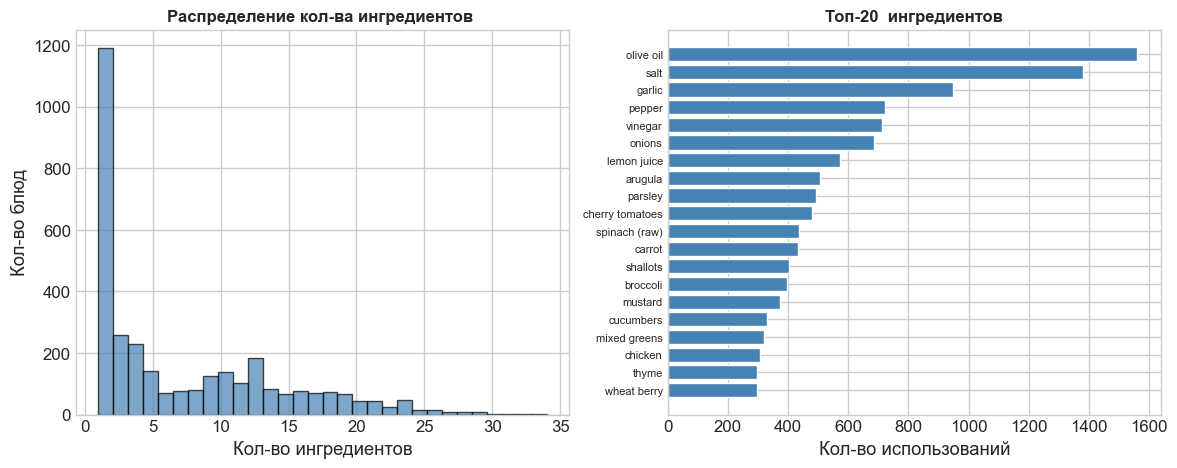

In [49]:
print(f"\n Статистика по количеству ингредиентов")


df_dish['num_ingredients'] = df_dish['ingredients'].apply(
    lambda x: len(str(x).split(';'))
)

# Подсчет частоты использования по ингредиентам
all_ingredient_ids = []
for ingredients_str in df_dish['ingredients']:
    ids = str(ingredients_str).split(';')
    all_ingredient_ids.extend(ids)

ingredient_counts = pd.Series(all_ingredient_ids).value_counts()

top_20 = ingredient_counts.head(20)

parsed_names = top_20.index.map(
    lambda raw_id: ingredients_dict.get( parse_ingredient_id(raw_id),   '????' )
)

print(df_dish['num_ingredients'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(df_dish['num_ingredients'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_title('Распределение кол-ва ингредиентов ', fontsize=12, fontweight='bold')
ax1.set_xlabel('Кол-во ингредиентов')
ax1.set_ylabel('Кол-во блюд')

ax2 = axes[1]
ax2.barh(range(len(top_20)), top_20.values, color='steelblue')
ax2.set_yticks(range(len(top_20)))
ax2.set_yticklabels(parsed_names, fontsize=8)
ax2.set_title('Топ-20  ингредиентов', fontsize=12, fontweight='bold')
ax2.set_xlabel('Кол-во использований')
ax2.invert_yaxis()

plt.show()


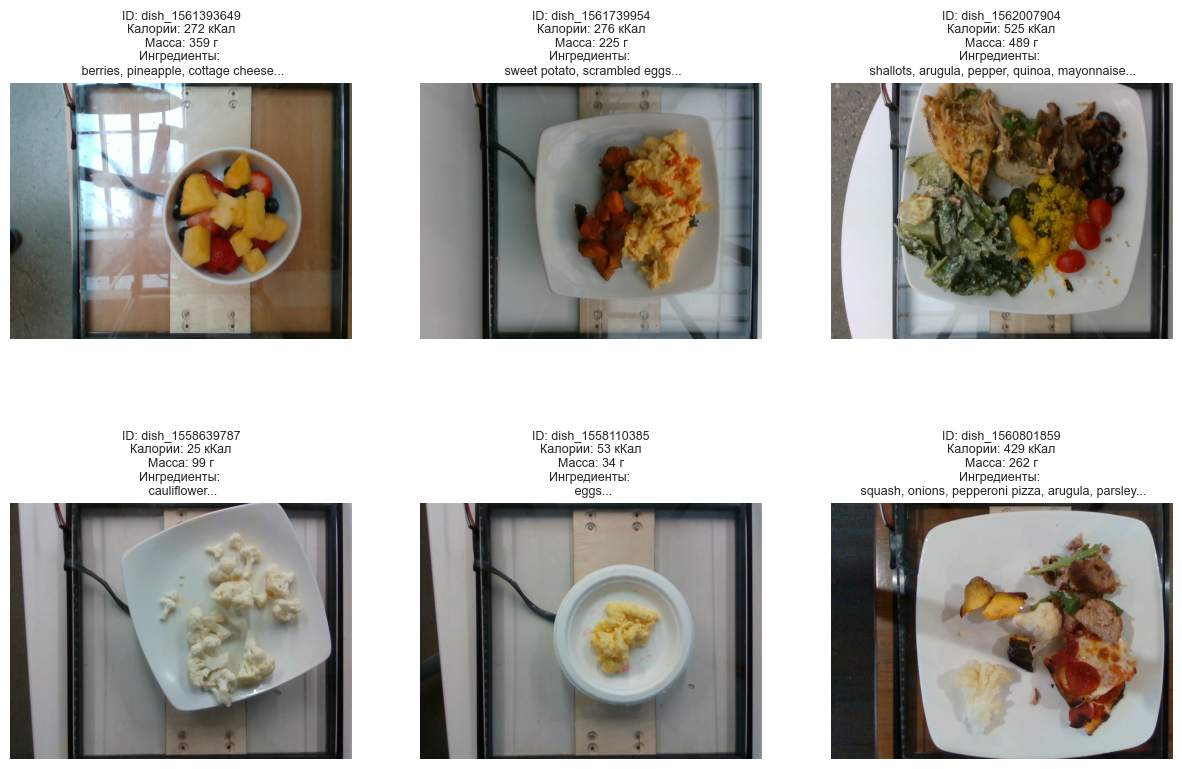

In [74]:

def visualize_dish_samples(df_dish, images_path, n_samples=6):
    sample_dishes = df_dish.sample(n=n_samples, random_state=42)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (_, dish) in enumerate(sample_dishes.iterrows()):
        dish_id = dish['dish_id']
        img_path = os.path.join(images_path, str(dish_id), 'rgb.png')
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[idx].imshow(img)
            
            # Получение названий ингредиентов
            ingr_ids = str(dish['ingredients']).split(';')
            ingr_names = []
            for ingr_id in ingr_ids[:5]:  # Первые 5 
                name = ingredients_dict.get(parse_ingredient_id(ingr_id))
                ingr_names.append(name)
            
            title = (f"ID: {dish_id}\n"
                     f"Калории: {dish['total_calories']:.0f} кКал\n"
                     f"Масса: {dish['total_mass']:.0f} г\n"
                     f"Ингредиенты: \n {', '.join(ingr_names[:5])}...")
            axes[idx].set_title(title, fontsize=9)
    
        
        axes[idx].axis('off')
    
    plt.show()

visualize_dish_samples(df_dish, IMAGES_PATH, n_samples=6)
